# PCoA - autosmds2 dataset

In [1]:
# disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

## autosmds2 dataset

In [2]:
# autosmds dataset
from scientisttools.datasets import autosmds2
autosmds2._fields

('actif', 'ind_sup', 'data')

In [3]:
# overall dataset
data = autosmds2.data
data.info()

<class 'pandas.DataFrame'>
Index: 15 entries, Toyota Corolla to Peugeot 504
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Toyota Corolla  15 non-null     float64
 1   Lada 1300       15 non-null     float64
 2   Alfasud TI      15 non-null     float64
 3   Lancia Beta     15 non-null     float64
 4   Mazda 9295      15 non-null     float64
 5   Fiat 132        15 non-null     float64
 6   Alfetta 1.66    15 non-null     float64
 7   Princess 1800   15 non-null     float64
 8   Audi 100        15 non-null     float64
 9   Taunus 2000     15 non-null     float64
 10  Opel Rekord     15 non-null     float64
 11  Datsun 200L     15 non-null     float64
dtypes: float64(12)
memory usage: 1.5+ KB


## Instanciation and training

In [4]:
# instanciation
from scientisttools import PCoA
clf = PCoA(ncp=2,ind_sup=[12,13,14],metric="precomputed")

### `fit` function

In [5]:
# fit function
clf.fit(data)

,metric,'precomputed'
,ind_sup,"[12, 13, ...]"
,ncp,2
,metric_params,None
,row_w,None
,tol,1e-07
Name,Type,Value
call_,call,call(Xtot= ...Peugeot 504'])
eig_,DataFrame,Eigen... 100.000000
evd_,evdResult,"evdResult(V=a...t64(6), ncp=2)"
ind_,ind,ind(coord= ...type: float64)


### `fit_transform` function

In [6]:
# fit_transform function - individuals coordinates
coord = clf.fit_transform(data)
coord

,Dim1,Dim2
Toyota Corolla,-514.368216,-65.795531
Lada 1300,-342.766700,14.875213
Alfasud TI,-322.669602,-85.483117
Lancia Beta,-290.429211,131.454491
Mazda 9295,151.927781,-33.798481
Fiat 132,-13.716817,46.156247
Alfetta 1.66,-44.526156,9.763934
Princess 1800,203.304446,15.419721
Audi 100,-7.649174,52.420252
Taunus 2000,353.774482,-132.490668


### `transform` function

In [7]:
# transform function - individuals coordinates
coord = clf.transform(autosmds2.actif)
coord

,Dim1,Dim2
Toyota Corolla,-514.369131,-65.807299
Lada 1300,-342.764257,14.876984
Alfasud TI,-322.670128,-85.479816
Lancia Beta,-290.430174,131.453222
Mazda 9295,151.928481,-33.797875
Fiat 132,-13.717766,46.160909
Alfetta 1.66,-44.526048,9.763145
Princess 1800,203.304619,15.421854
Audi 100,-7.649600,52.422569
Taunus 2000,353.771823,-132.495863


In [8]:
# attributes
from scientisttools import sprintf
sprintf(clf)


**Results of the Principal Coordinates Analysis (PCoA)**

*The results are available in the following objects:

name       description
---------  -----------------------------------------
.call_     summary called parameters
.eig_      eigenvalues
.evd_      results for eigen values decomposition
.ind_      results for the individuals
.ind_sup_  results for the supplementary individuals



## Eigen values

In [9]:
# eigen values
from scientisttools import get_eig
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,1.110688e+06,1.031471e+06,93.065694,93.065694
Dim2,7.921646e+04,7.739345e+04,6.637630,99.703325
Dim3,1.823007e+03,3.826317e+02,0.152752,99.856076
Dim4,1.440375e+03,1.227625e+03,0.120691,99.976767
Dim5,2.127499e+02,1.482255e+02,0.017827,99.994593
Dim6,6.452439e+01,NaN,0.005407,100.000000


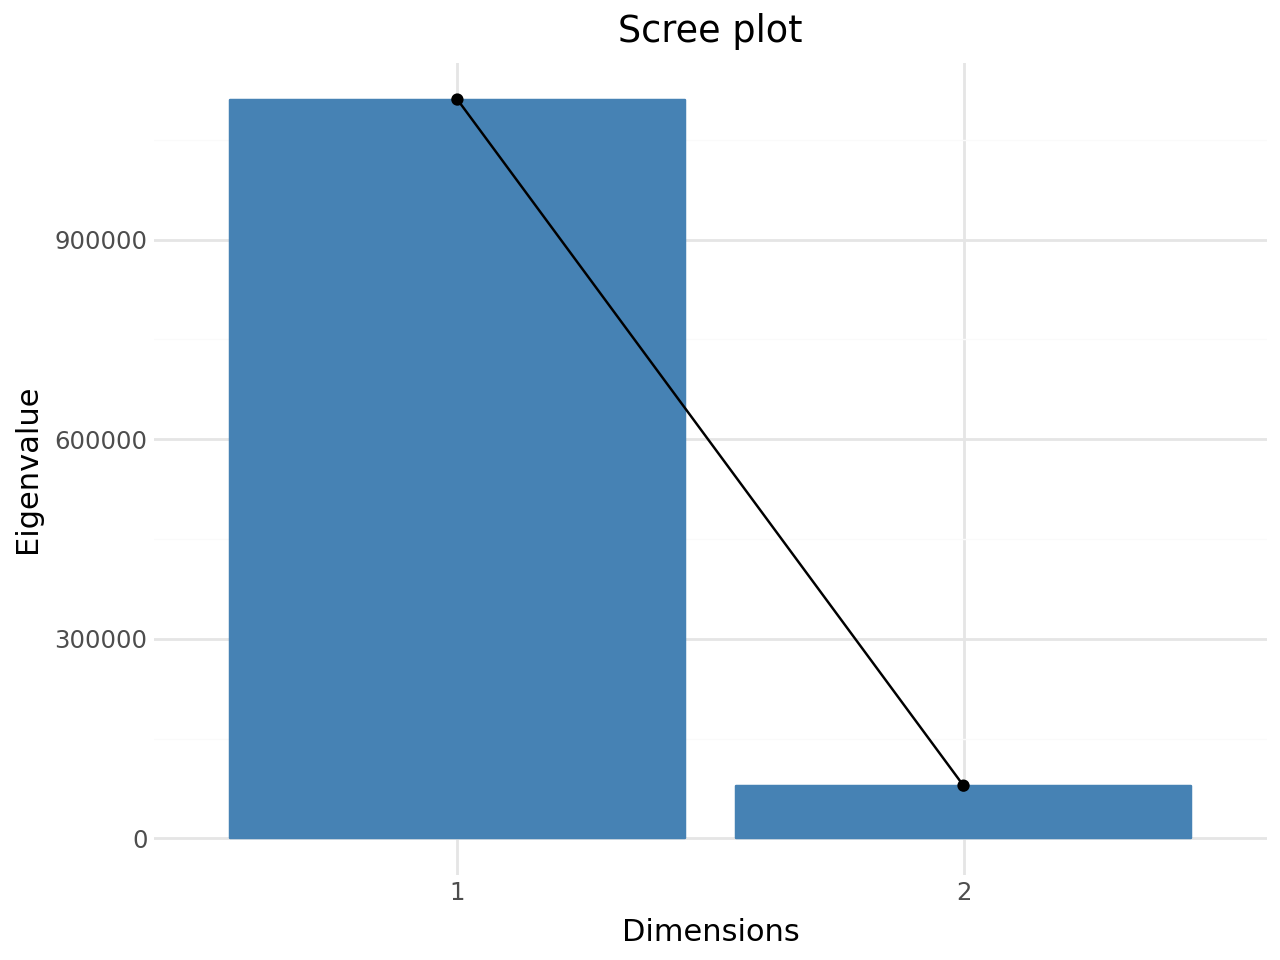

None


In [10]:
# scree plot - eigenvalue
from scientisttools import fviz_screeplot
p = fviz_screeplot(obj=clf,choice ="eigenvalue")
print(p.show())

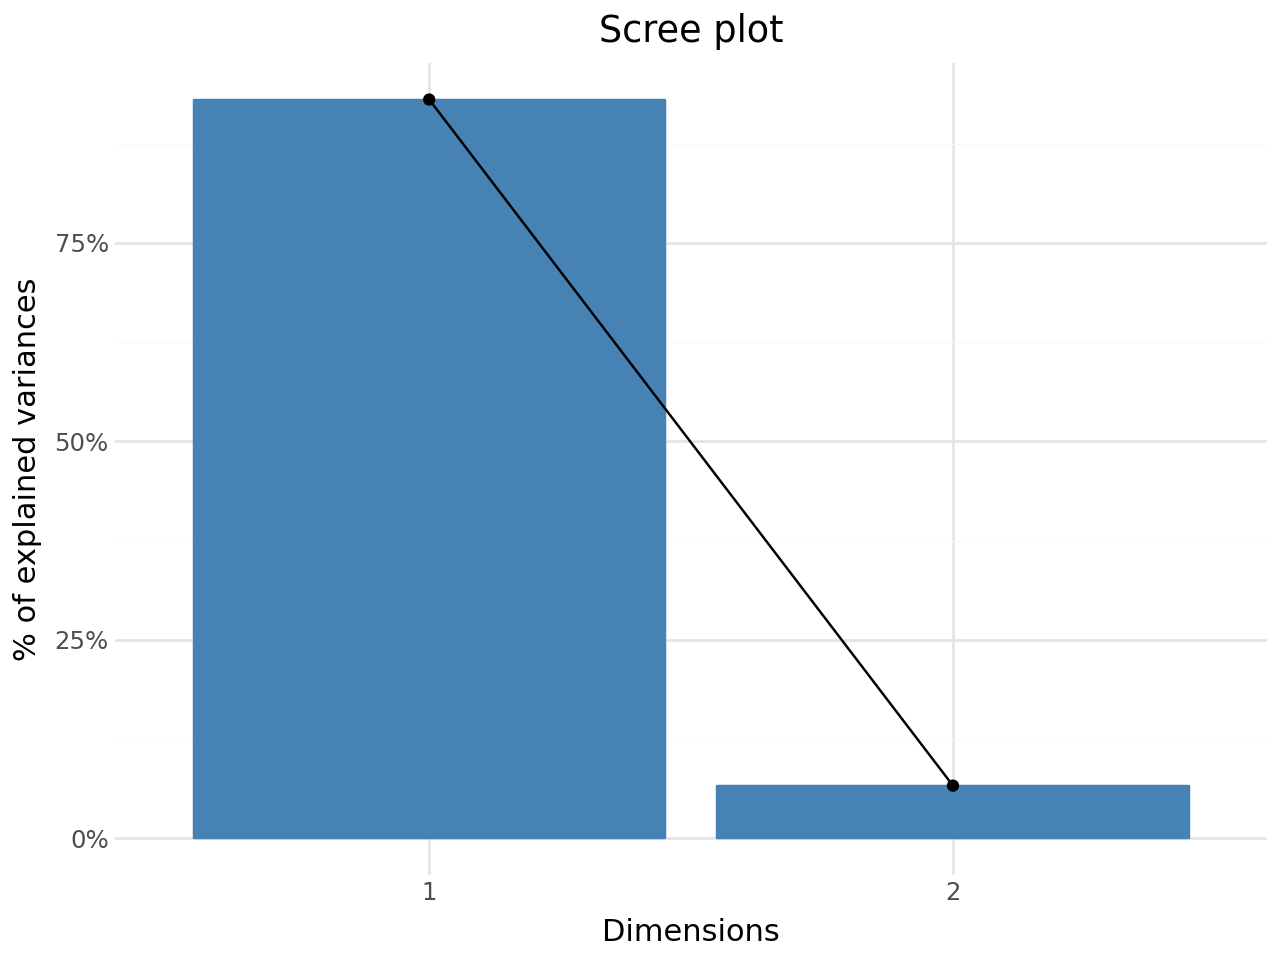

None


In [11]:
# scree plot - proportion
p = fviz_screeplot(obj=clf,choice ="proportion")
print(p.show())

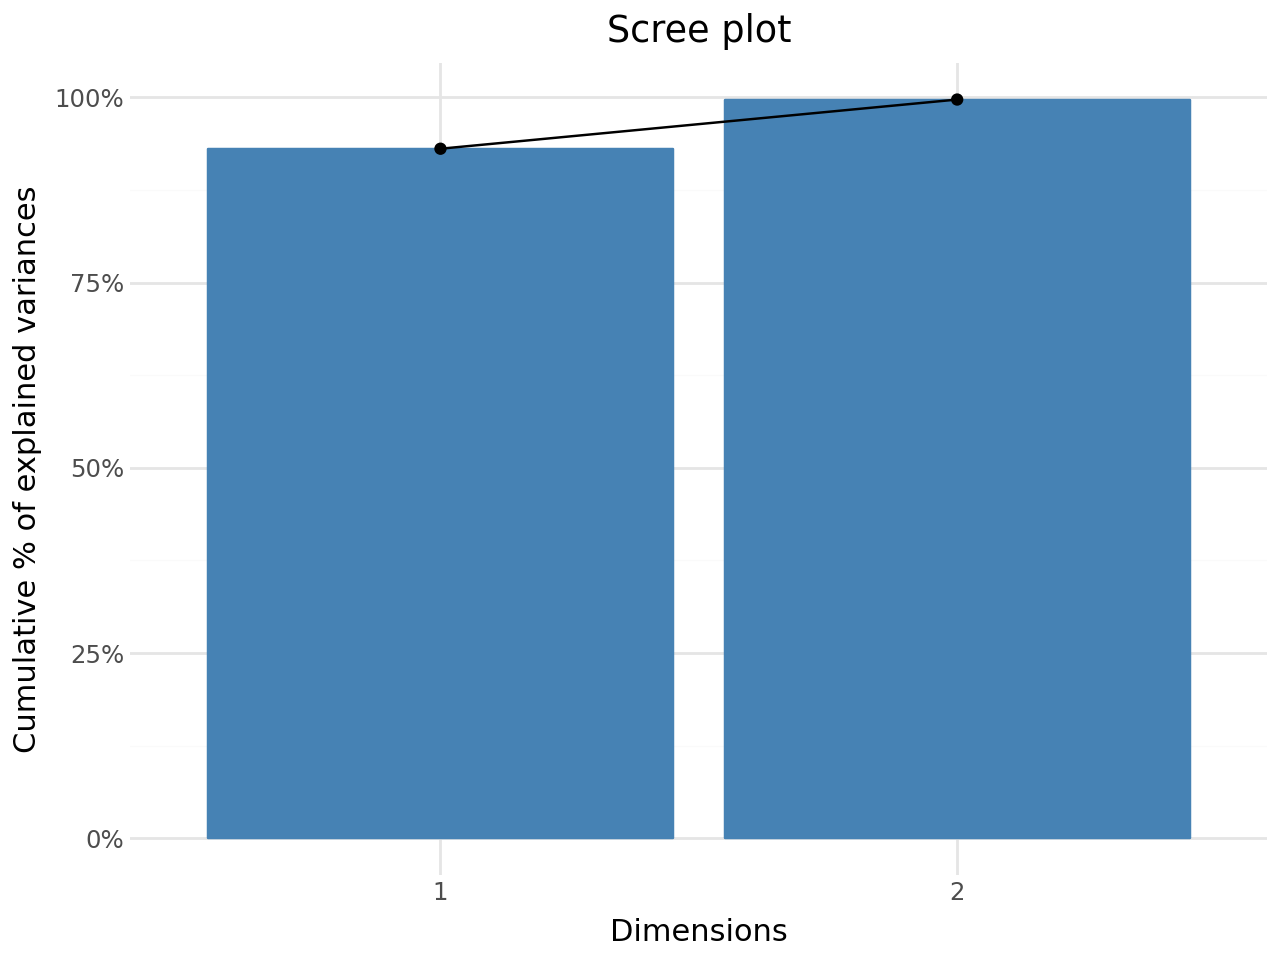

None


In [12]:
# scree plot - cumulative
p = fviz_screeplot(obj=clf,choice ="cumulative")
print(p.show())

## Indivduals informations

In [13]:
# individuals informations
ind = clf.ind_
ind._fields

('coord', 'contrib', 'cos2', 'dist2')

### Individuals coordinates

In [14]:
# individuals coordinates
ind.coord

,Dim1,Dim2
Toyota Corolla,-514.368216,-65.795531
Lada 1300,-342.766700,14.875213
Alfasud TI,-322.669602,-85.483117
Lancia Beta,-290.429211,131.454491
Mazda 9295,151.927781,-33.798481
Fiat 132,-13.716817,46.156247
Alfetta 1.66,-44.526156,9.763934
Princess 1800,203.304446,15.419721
Audi 100,-7.649174,52.420252
Taunus 2000,353.774482,-132.490668


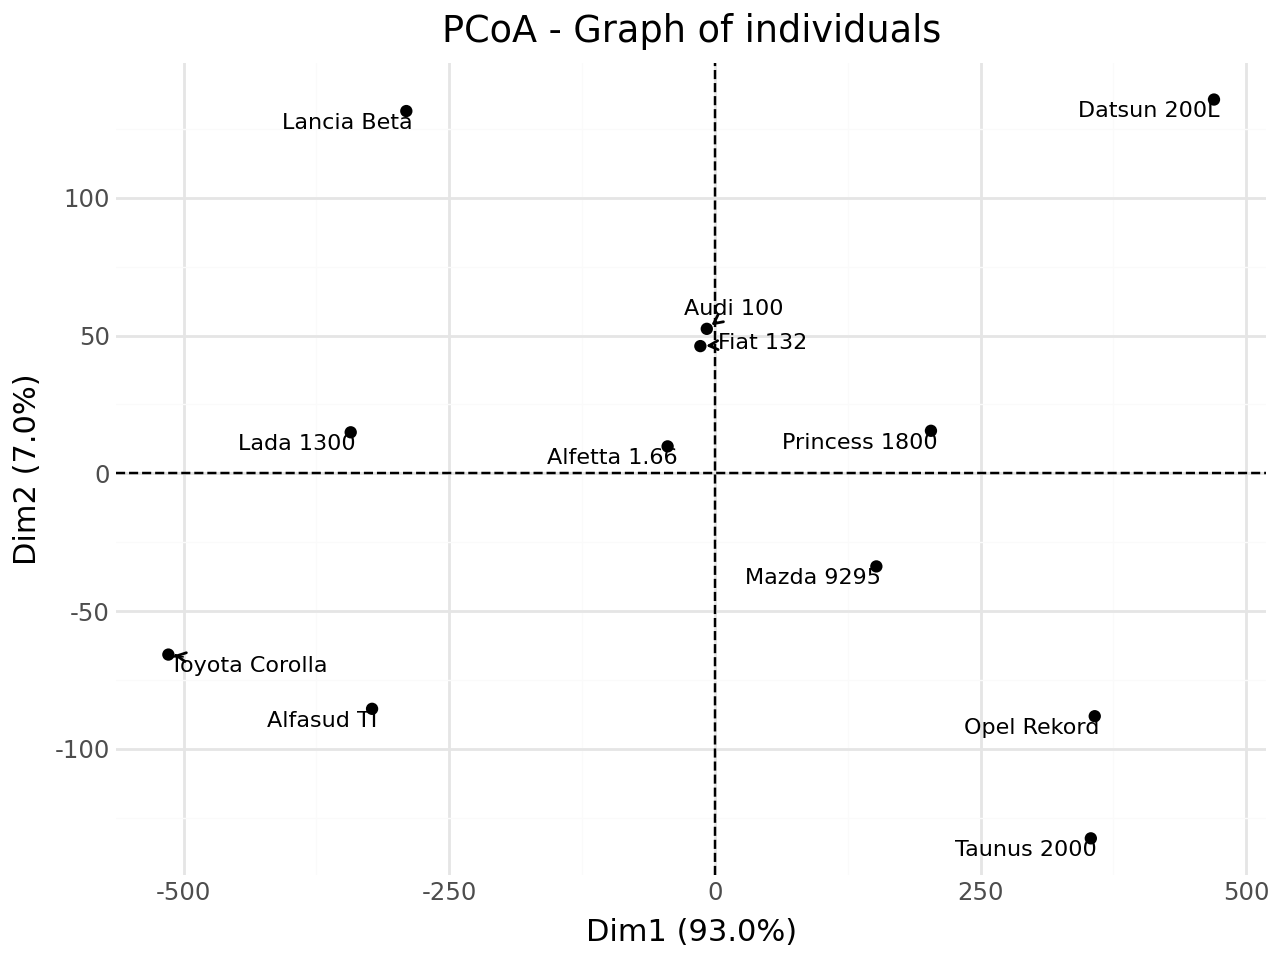

None


In [15]:
# graph of individuals
from scientisttools import fviz_pcoa
p = fviz_pcoa(
    obj = clf,
    choice = "ind",
    repel = True,
    ind_sup = False
)
print(p.show())

### Individuals contributions

In [16]:
# individuals contributions
ind.contrib

,Dim1,Dim2
Toyota Corolla,0.238208,0.054648
Lada 1300,0.105780,0.002793
Alfasud TI,0.093740,0.092246
Lancia Beta,0.075943,0.218140
Mazda 9295,0.020782,0.014420
Fiat 132,0.000169,0.026893
Alfetta 1.66,0.001785,0.001203
Princess 1800,0.037214,0.003001
Audi 100,0.000053,0.034688
Taunus 2000,0.112684,0.221593


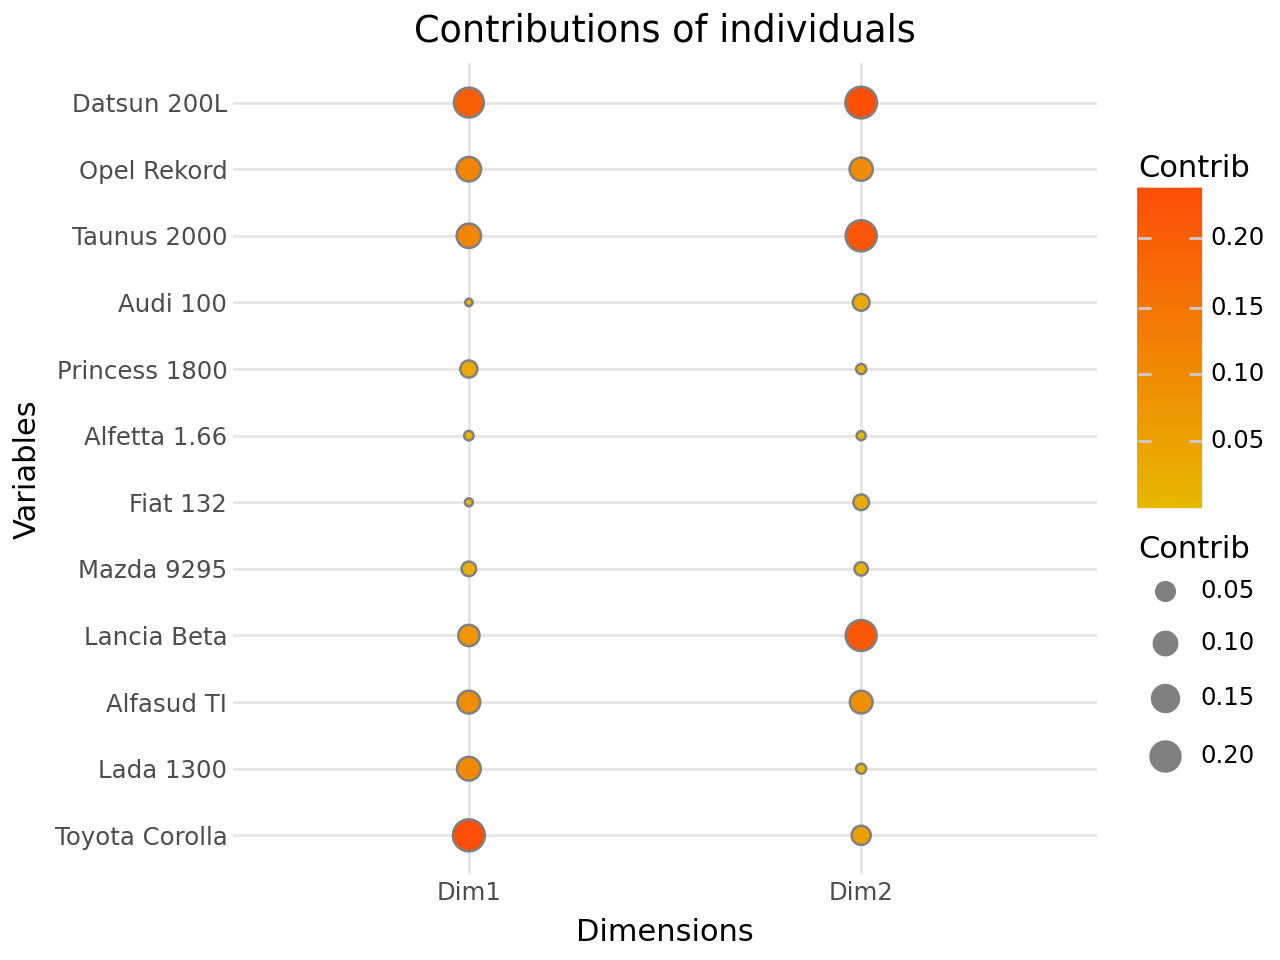

None


In [17]:
# graph 
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X=ind.contrib,
    legend_title="Contrib",
    title="Contributions of individuals"
)
print(p.show())

### Individuals cos2

In [18]:
# individuals cos2
ind.cos2

,Dim1,Dim2
Toyota Corolla,0.983022,0.016085
Lada 1300,0.995434,0.001875
Alfasud TI,0.932092,0.065419
Lancia Beta,0.829400,0.169916
Mazda 9295,0.948873,0.046960
Fiat 132,0.077378,0.876132
Alfetta 1.66,0.692822,0.033315
Princess 1800,0.987314,0.005680
Audi 100,0.015597,0.732522
Taunus 2000,0.876764,0.122970


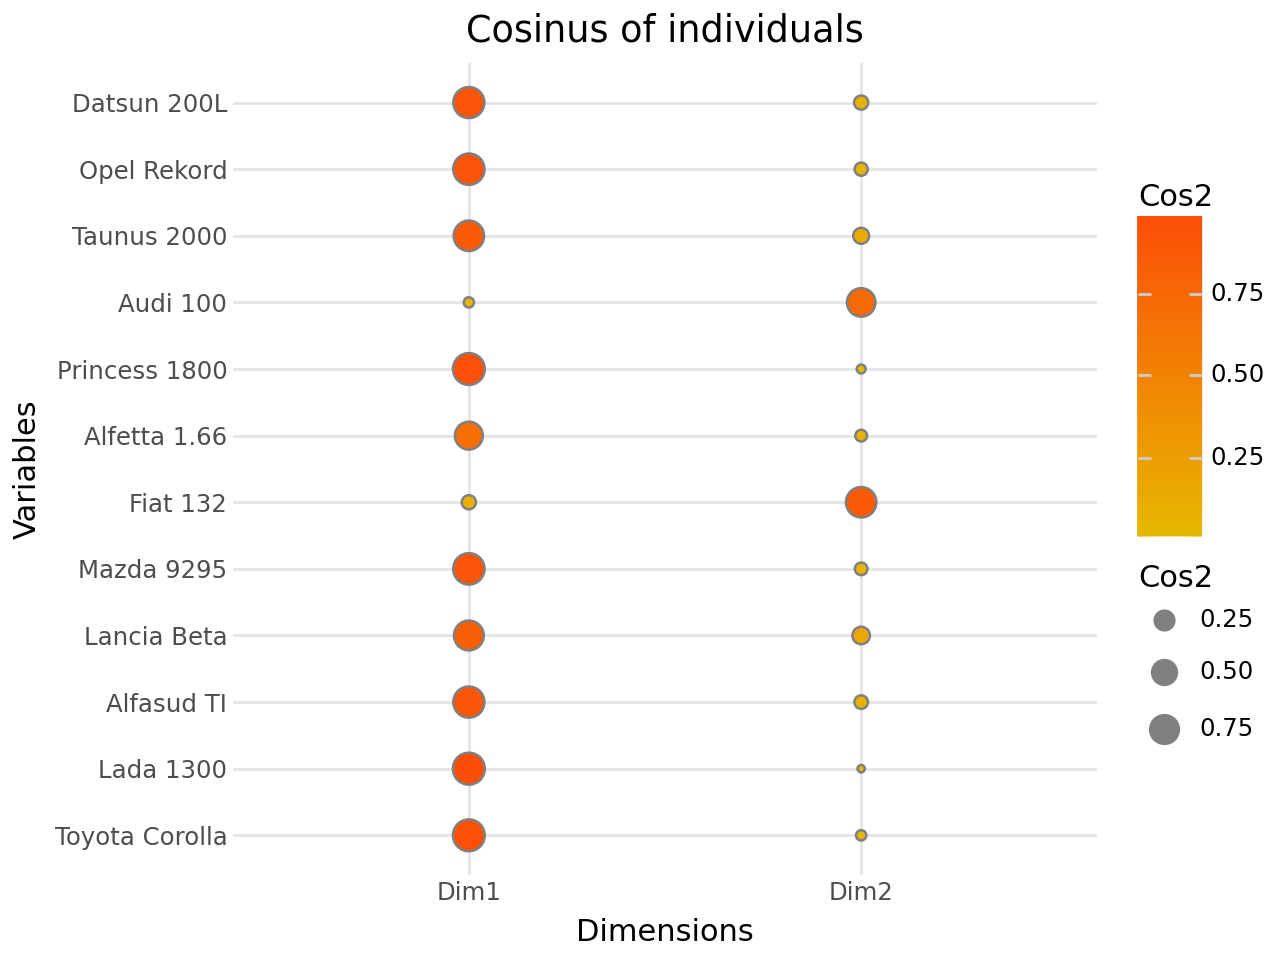

None


In [19]:
# graph of cosinus
p = fviz_corrplot(
    X=ind.cos2,
    legend_title="Cos2",
    title="Cosinus of individuals"
)
print(p.show())

### Individuals dist2

In [20]:
# individuals dist2
ind.dist2.to_frame()

,Sq. Dist.
Toyota Corolla,269144.097222
Lada 1300,118027.930556
Alfasud TI,111701.097222
Lancia Beta,101698.930556
Mazda 9295,24325.763889
Fiat 132,2431.597222
Alfetta 1.66,2861.597222
Princess 1800,41863.763889
Audi 100,3751.263889
Taunus 2000,142748.097222


## Shepard diagram

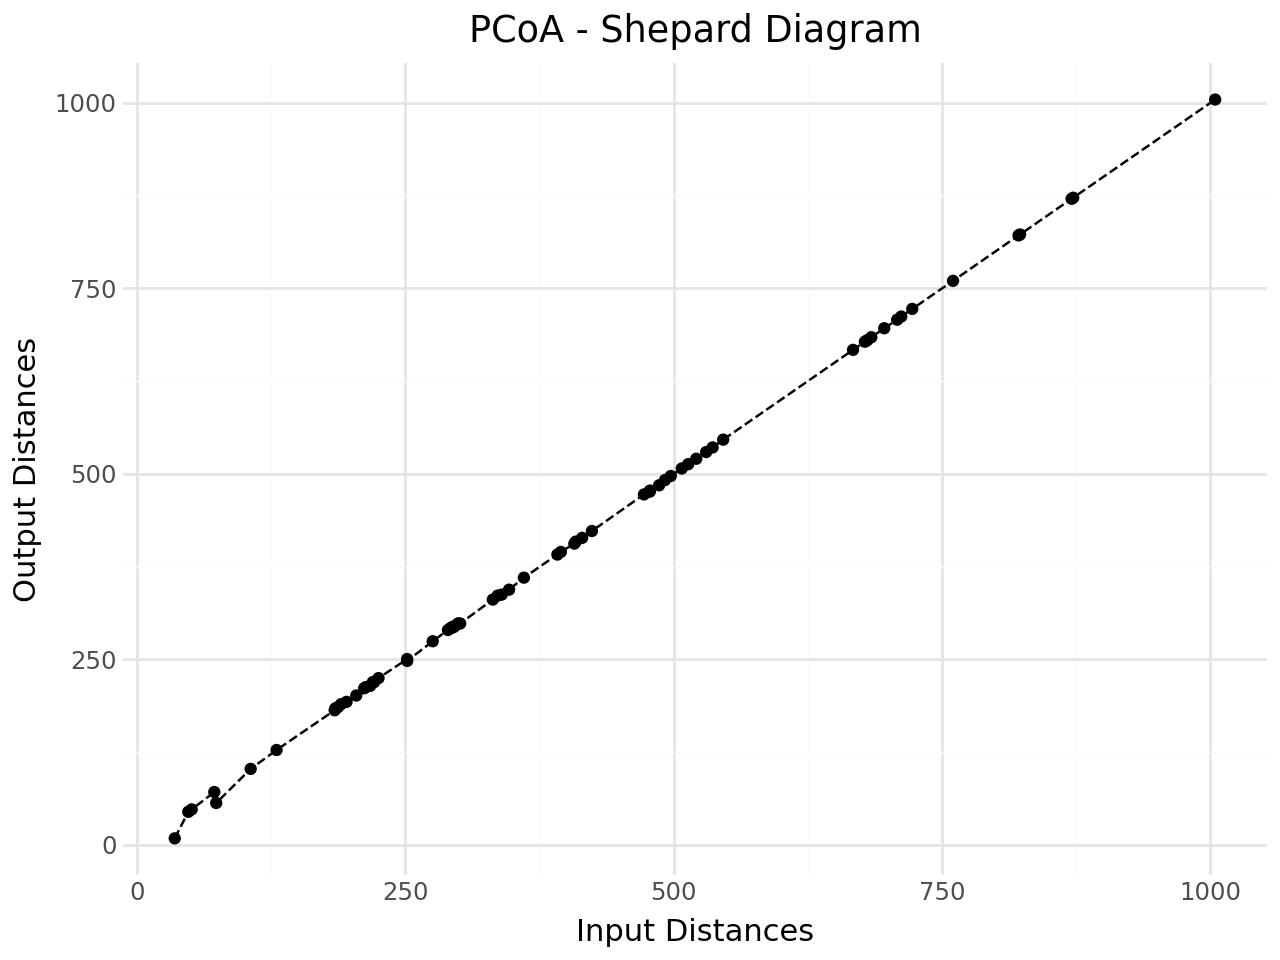

None


In [21]:
# shepard diagram
from scientisttools import fviz_pcoa_shepard
p = fviz_pcoa_shepard(clf)
print(p.show())

## Supplementary individuals informations

In [22]:
# supplementary individuals informations
ind_sup = clf.ind_sup_
ind_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary individuals coordinates

In [23]:
# supplementary individuals coordinates
ind_sup.coord

,Dim1,Dim2
Citroen GS Club,-418.260083,19.707020
Renault 30,1065.891142,-165.824064
Peugeot 504,201.478597,16.499780


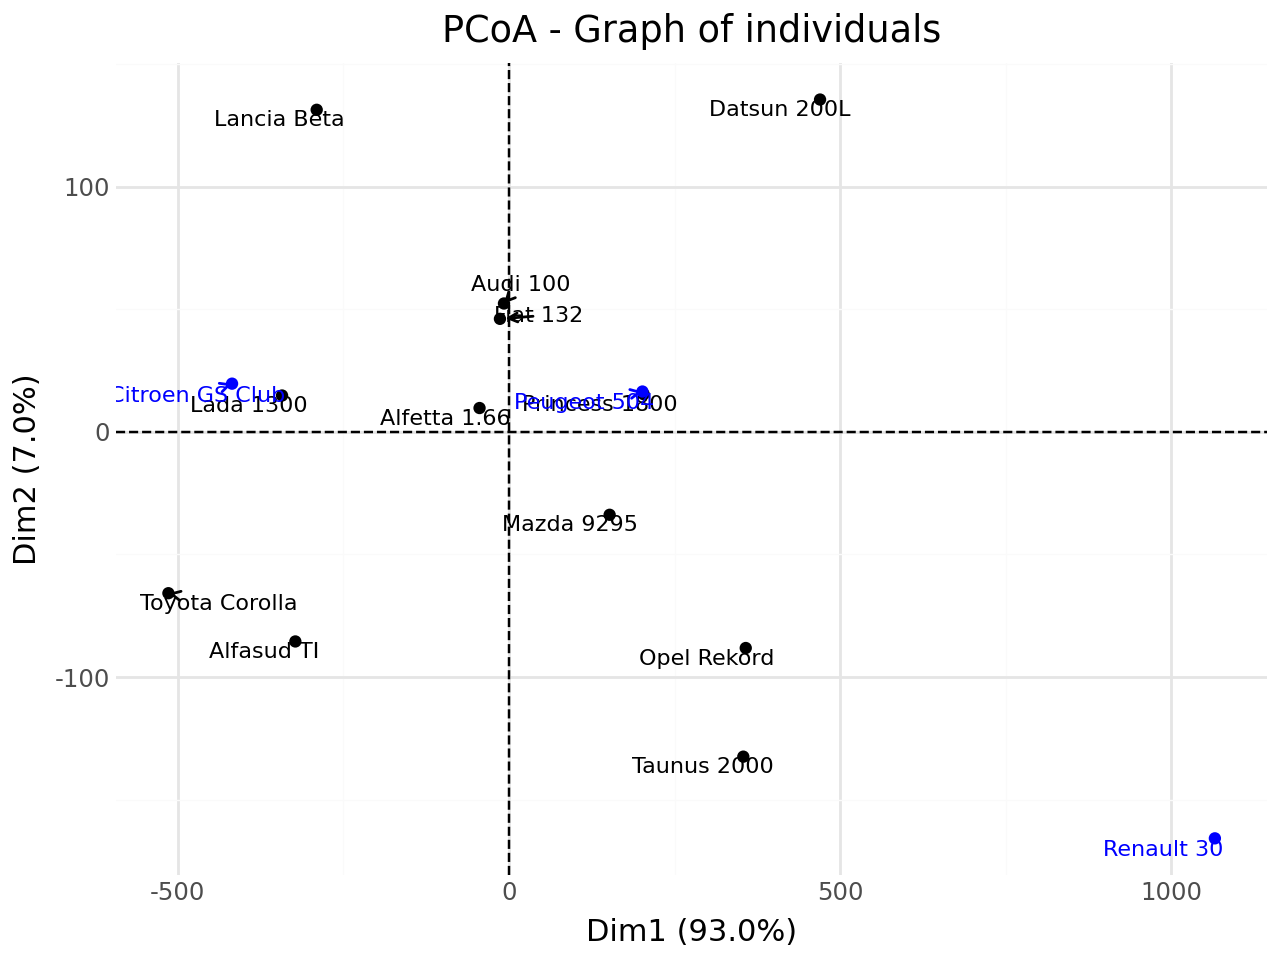

None


In [24]:
# graph of individuals with supplementary individuals
from scientisttools import fviz_pcoa
p = fviz_pcoa(
    obj = clf,
    choice = "ind",
    repel = True,
    ind_sup = True
)
print(p.show())

### Supplementary individuals cos2

In [25]:
# supplementary individuals cos2
ind_sup.cos2

,Dim1,Dim2
Citroen GS Club,0.996841,0.002213
Renault 30,0.975334,0.023606
Peugeot 504,0.982934,0.006592


### Supplementary individuals dist2

In [26]:
# supplementary individuals dist2
ind_sup.dist2.to_frame()

,Sq. Dist.
Citroen GS Club,1.754959e+05
Renault 30,1.164856e+06
Peugeot 504,4.129843e+04


## Others functions

### Summary - `summary`

In [27]:
# summary
from scientisttools import summary
summary(clf)

                     Principal Coordinates Analysis - Results                     

Importance of components:
        Eigenvalue    Difference  Proportion (%)  Cumulative (%)
Dim1  1.110688e+06  1.031471e+06         93.0657         93.0657
Dim2  7.921646e+04  7.739345e+04          6.6376         99.7033

Individuals (the 10 first):
                    Dim1    cos2     ctr      Dim2    cos2     ctr
Toyota Corolla -514.3682  0.9830  0.2382  -65.7955  0.0161  0.0546
Lada 1300      -342.7667  0.9954  0.1058   14.8752  0.0019  0.0028
Alfasud TI     -322.6696  0.9321  0.0937  -85.4831  0.0654  0.0922
Lancia Beta    -290.4292  0.8294  0.0759  131.4545  0.1699  0.2181
Mazda 9295      151.9278  0.9489  0.0208  -33.7985  0.0470  0.0144
Fiat 132        -13.7168  0.0774  0.0002   46.1562  0.8761  0.0269
Alfetta 1.66    -44.5262  0.6928  0.0018    9.7639  0.0333  0.0012
Princess 1800   203.3044  0.9873  0.0372   15.4197  0.0057  0.0030
Audi 100         -7.6492  0.0156  0.0001   52.4203  0.7325  0.0

In [28]:
# summary formatting markdown
summary(clf,to_markdown=True)

                     Principal Coordinates Analysis - Results                     

Importance of components:
           Eigenvalue       Difference    Proportion (%)    Cumulative (%)
----  ---------------  ---------------  ----------------  ----------------
Dim1      1.11069e+06      1.03147e+06           93.0657           93.0657
Dim2  79216.5          77393.4                    6.6376           99.7033

Individuals (the 10 first):
                     Dim1    cos2     ctr       Dim2    cos2     ctr
--------------  ---------  ------  ------  ---------  ------  ------
Toyota Corolla  -514.368   0.983   0.2382   -65.7955  0.0161  0.0546
Lada 1300       -342.767   0.9954  0.1058    14.8752  0.0019  0.0028
Alfasud TI      -322.67    0.9321  0.0937   -85.4831  0.0654  0.0922
Lancia Beta     -290.429   0.8294  0.0759   131.454   0.1699  0.2181
Mazda 9295       151.928   0.9489  0.0208   -33.7985  0.047   0.0144
Fiat 132         -13.7168  0.0774  0.0002    46.1562  0.8761  0.0269
Alfetta 1